## CSCI 3202 Spring 2025
## Homework 8
## Due April 30, 2025
### 80 points

---


In this assignment, you will learn how to train, validate, and evaluate a Decision Tree Classifier on a given dataset. You will practice using metrics such as accuracy, cross-validation, and pruning to improve your model's performance.

### Instructions:

This dataset contains information about different attributes of employees from a company. There are 14999 employees records and 10 feature columns.  The columns are:

    satisfaction_level: Employee satisfaction score (1-5 scale).
    last_evaluation: Score on last evaluation (1-5 scale).
    number_project: Number of projects employee worked on.
    average_monthly_hours: Average hours worked in a month.
    time_spend_company: Number of years spent with the company.
    work_accident: If an employee had a workplace accident (yes/no).
    left: If an employee has left the company (yes/no).
    promotion_last_5years: Number of promotions in last 5 years.
    Department: Department of the employee.
    Salary: Annual salary of employee.

For this assignment, your job is to predict the column `left` using a decision tree and then use it to explain to HR why employees stay or leave their job.

In [1]:
# Load libraries needed
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, precision_score
import matplotlib.pyplot as plt

In [2]:
# Read in the data
hr=pd.read_csv("HR_comma_sep.csv")

In [3]:
# Print the first 10 lines of the dataset for verification
hr.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


**1.  Check the data.**  (10 points) Determine if the number of data points matches your expectation.  Remove any missing values and recode the data to numerical values.  There are more categories for sales than we want.  Combine the following categories for 'sales' to create a new variable with 3 possible levels, sales= 1, technical= 2, support= 3
                            
```python
hr['position'] = hr['sales'].map({'sales':1,'technical':2,'support':3,'IT':3,
                                  'product_mng':1,'marketing':1,'RandD':2,
                                  'accounting':3,'hr':3,'management':3})
```

In [4]:
position_map = {
    'sales': 1, 'product_mng': 1, 'marketing': 1,
    'technical': 2, 'RandD': 2,
    'support': 3, 'IT': 3, 'accounting': 3, 'hr': 3, 'management': 3
}
hr['position'] = hr['sales'].map(position_map)
hr['salary_level'] = hr['salary'].map({'low': 1, 'medium': 2, 'high': 3})

**2. Datasets**. (10 points) Create datasets for y and X, where y is the variable we are predicting and X contains the features.
Create a datsets for training and another for testing by randomly selecting 80% of the data for training and 20% for testing.  Call your datasets X_train, y_train, X_test, y_test

In [5]:
feature_cols = [
    'satisfaction_level', 'last_evaluation', 'number_project',
    'average_montly_hours', 'time_spend_company',
    'Work_accident', 'promotion_last_5years',
    'position', 'salary_level'
]
X = hr[feature_cols]
y = hr['left']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**3. Fit Decision Tree.**  (20 points)  Build a decision tree classifier on the training data.  Use the sklearn module or any other modules which create decison trees.  

In [6]:
full_clf = DecisionTreeClassifier(random_state=42)
full_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

**4. Print Tree.** (10 points). Print your decision tree.  How well does the tree fit our data?  Is the tree overfit?  Why or not?

In [7]:
train_acc = full_clf.score(X_train, y_train)
test_acc = full_clf.score(X_test, y_test)
cv_scores = cross_val_score(full_clf, X, y, cv=5)
print(f"\nFull Tree Training Accuracy: {train_acc:.3f}")
print(f"Full Tree Test Accuracy:     {test_acc:.3f}")
print(f"Full Tree 5-Fold CV:         {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

print("\nFull Tree Rules (first 10 lines):")
full_rules = export_text(full_clf, feature_names=feature_cols).split('\n')
print("\n".join(full_rules[:10]))


Full Tree Training Accuracy: 1.000
Full Tree Test Accuracy:     0.975
Full Tree 5-Fold CV:         0.974 ± 0.009

Full Tree Rules (first 10 lines):
|--- satisfaction_level <= 0.47
|   |--- number_project <= 2.50
|   |   |--- last_evaluation <= 0.57
|   |   |   |--- last_evaluation <= 0.44
|   |   |   |   |--- class: 0
|   |   |   |--- last_evaluation >  0.44
|   |   |   |   |--- average_montly_hours <= 125.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- average_montly_hours >  125.50
|   |   |   |   |   |--- average_montly_hours <= 163.50


**5. Improve Tree Fit.** (20 points).  Improve the fit of your decision tree by limiting the depth of the tree.  Explain how well your new tree fits the data.  What depth did you choose for your tree?  Why?

In [8]:
pruned_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
pruned_clf.fit(X_train, y_train)

print(f"Pruned test acc: {pruned_clf.score(X_test, y_test):.3f}")

Pruned test acc: 0.967


**6. Interpret.**  (10 points).  Print your improved decision tree.  Explain how to use this tree to predict a new observation.

|--- satisfaction_level <= 0.47
|   |--- number_project <= 2.50
|   |   |--- last_evaluation <= 0.57
|   |   |   |--- last_evaluation <= 0.44
|   |   |   |   |--- class: 0
|   |   |   |--- last_evaluation >  0.44
|   |   |   |   |--- class: 1
|   |   |--- last_evaluation >  0.57
|   |   |   |--- average_montly_hours <= 280.00
|   |   |   |   |--- class: 0
|   |   |   |--- average_montly_hours >  280.00
|   |   |   |   |--- class: 1
|   |--- number_project >  2.50
|   |   |--- satisfaction_level <= 0.11
|   |   |   |--- class: 1
|   |   |--- satisfaction_level >  0.11
|   |   |   |--- number_project <= 6.50
|   |   |   |   |--- class: 0
|   |   |   |--- number_project >  6.50
|   |   |   |   |--- class: 1
|--- satisfaction_level >  0.47
|   |--- time_spend_company <= 4.50
|   |   |--- average_montly_hours <= 290.50
|   |   |   |--- number_project <= 6.50
|   |   |   |   |--- class: 0
|   |   |   |--- number_project >  6.50
|   |   |   |   |--- class: 1
|   |   |--- average_montly_hours 

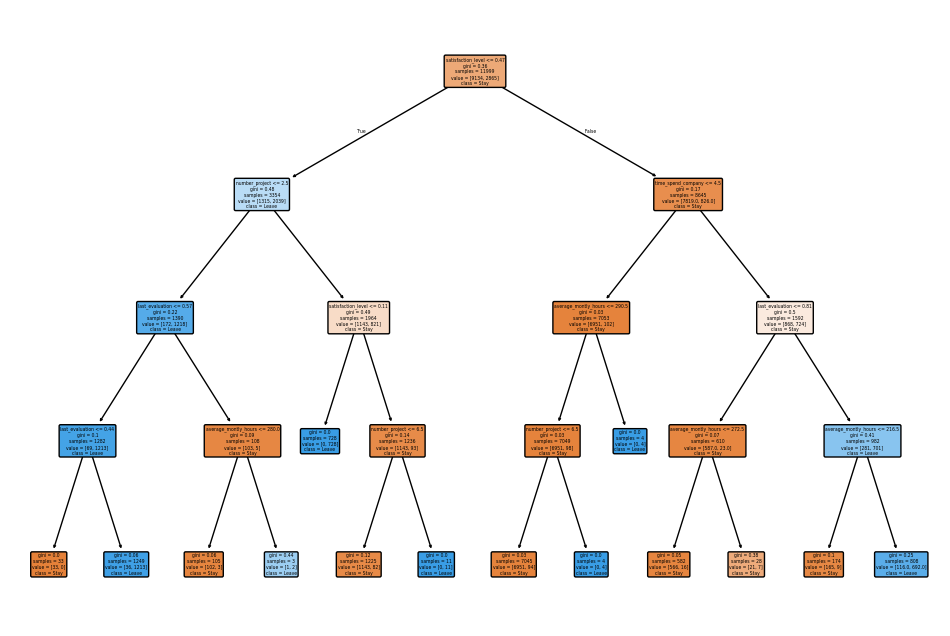

In [9]:
print(export_text(pruned_clf, feature_names=feature_cols))

plt.figure(figsize=(12, 8))
plot_tree(
    pruned_clf,
    filled=True,
    feature_names=feature_cols,
    class_names=['Stay', 'Leave'],
    rounded=True,
    precision=2
)
plt.show()

**7. Explain.**  (10 points). Using this decision tree.  In a paragraph or two, explain to HR why employees stay or leave their jobs.

Based on the decision tree analysis, the biggest factor predicting whether employees leave or stay at their job is their satisfaction level. Employees who have a low satisfaction score (≤ 0.47) are generally more likely to leave, but this isn't always the case. For example, employees who have low satisfaction but are assigned few projects and have very low evaluations tend to stay, possibly because they're newer or not feeling overwhelmed yet. However, employees with low satisfaction who receive moderate evaluations or who work excessive monthly hours (over 280 hours per month) often end up leaving, probably due to feeling underappreciated or burnt out. Similarly, those who handle many projects but have extremely low satisfaction (≤ 0.11) or are overloaded (more than 6.5 projects) also tend to leave.

Employees who report higher satisfaction (> 0.47) generally stay at the company, especially if they've worked there fewer than about 4.5 years and aren't overloaded with hours. Still, there's a noticeable risk of leaving around the 4-5 year mark even for satisfied employees, especially if their workload increases significantly or if their performance evaluations start to decline. Overall, this suggests HR should focus on boosting employee satisfaction, balancing workloads, and offering growth or promotions around mid-career points to help retain employees.